<div style="
    background: linear-gradient(135deg, #0F172A, #164E63);
    border-radius: 18px;
    padding: 28px;
    color: white;
    text-align: center;
    margin-bottom: 20px;
">

<div style="font-size: 13px; letter-spacing: 2px; font-weight: 700; color: #67E8F9;">
BINX TECH • AI & MACHINE LEARNING
</div>

<div style="font-size: 30px; font-weight: 800; margin-top: 10px;">
🩺 Diabetes Patient Clustering
</div>

<div style="font-size: 17px; margin-top: 8px; color: #CFFAFE;">
Week 5 • Day 1 — Unsupervised Learning & K-Means
</div>

<div style="
    margin-top: 18px;
    display: inline-block;
    background: #0E7490;
    padding: 8px 18px;
    border-radius: 20px;
    font-size: 13px;
    font-weight: 700;
">
K-MEANS CLUSTERING
</div>

</div>

<div style="
    background:#F8FAFC;
    border-left:5px solid #0891B2;
    border-radius:12px;
    padding:20px 24px;
    margin:15px 0;
">

<div style="color:#0E7490; font-size:12px; font-weight:800; letter-spacing:1.5px;">
📊 DATASET INTRODUCTION
</div>

<div style="color:#0F172A; font-size:22px; font-weight:800; margin-top:7px;">
🩺 Diabetes Dataset
</div>

<div style="color:#334155; font-size:14px; line-height:1.8; margin-top:10px;">
In this notebook, we apply <b>unsupervised learning</b> techniques to a diabetes-related dataset.
The dataset contains numerical health measurements that can be used to discover natural groups
of patients based on similarities in their characteristics.
<br><br>

Unlike supervised learning, we will <b>not use the diabetes outcome as a target for clustering</b>.
Instead, K-Means will search for hidden patterns and naturally occurring patient groups.
</div>

</div>

<div style="
    background:linear-gradient(135deg,#ECFEFF,#F0F9FF);
    border:1px solid #A5F3FC;
    border-radius:14px;
    padding:20px 24px;
    margin:15px 0;
">

<div style="color:#0E7490; font-size:12px; font-weight:800; letter-spacing:1.5px;">
🧭 TODAY'S WORKFLOW
</div>

<div style="color:#0F172A; font-size:21px; font-weight:800; margin-top:7px;">
From Raw Data → Patient Clusters
</div>

<div style="color:#334155; font-size:14px; line-height:2; margin-top:10px;">
📥 Load and inspect the dataset<br>
🔎 Check data quality and missing values<br>
🎯 Select meaningful numerical features<br>
📏 Scale the features using StandardScaler<br>
🔵 Apply K-Means clustering<br>
📉 Find a suitable <b>k</b> using the Elbow Method<br>
📐 Compare candidate clusters using Silhouette Score<br>
🎯 Train the final K-Means model<br>
🎨 Visualize the discovered patient groups<br>
🧠 Interpret the characteristics of each cluster
</div>

</div>

<div style="
    background:linear-gradient(135deg,#0F172A,#164E63);
    border-radius:14px;
    padding:18px 22px;
    color:white;
    margin:18px 0;
">

<div style="color:#67E8F9; font-size:11px; font-weight:800; letter-spacing:1.5px;">
01 • SETUP
</div>

<div style="font-size:24px; font-weight:800; margin-top:5px;">
⚙️ Libraries & Environment
</div>

<div style="color:#CFFAFE; font-size:14px; margin-top:7px;">
Import the tools required for data analysis, scaling, clustering, evaluation, and visualization.
</div>

</div>

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from IPython.display import display, HTML

print("Libraries imported successfully ✓")

Libraries imported successfully ✓


<div style="
    background:#F8FAFC;
    border-left:5px solid #0891B2;
    border-radius:12px;
    padding:18px 22px;
    margin:15px 0;
">

<div style="color:#0E7490; font-size:11px; font-weight:800; letter-spacing:1.5px;">
02 • DATA LOADING
</div>

<div style="color:#0F172A; font-size:22px; font-weight:800; margin-top:5px;">
📥 Load the Dataset
</div>

<div style="color:#475569; font-size:14px; line-height:1.7; margin-top:8px;">
We now load the Diabetes dataset into a Pandas DataFrame.
The dataset will be inspected before selecting the features used for clustering.
</div>

</div>

In [9]:
# Load Diabetes Dataset

df_diabetes = pd.read_csv("heart_disease_uci.csv", sep=";")

display(HTML(f"""
<div style="
    background:#F0FDFA;
    border:1px solid #99F6E4;
    border-radius:14px;
    padding:18px 22px;
    margin:12px 0;
">
<div style="color:#0F766E; font-size:11px; font-weight:800; letter-spacing:1.5px;">
DATASET LOADED ✓
</div>

<div style="display:flex; gap:12px; margin-top:10px;">

<div style="
    flex:1;
    background:#ECFEFF;
    border:1px solid #A5F3FC;
    border-radius:10px;
    padding:12px;
">
<div style="color:#0E7490; font-size:10px; font-weight:800;">ROWS</div>
<div style="color:#164E63; font-size:22px; font-weight:800;">
{df_diabetes.shape[0]}
</div>
</div>

<div style="
    flex:1;
    background:#F0F9FF;
    border:1px solid #BAE6FD;
    border-radius:10px;
    padding:12px;
">
<div style="color:#0369A1; font-size:10px; font-weight:800;">COLUMNS</div>
<div style="color:#075985; font-size:22px; font-weight:800;">
{df_diabetes.shape[1]}
</div>
</div>

</div>
</div>
"""))

display(df_diabetes.head())

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


<div style="
    background:linear-gradient(135deg,#ECFEFF,#F8FAFC);
    border:1px solid #A5F3FC;
    border-radius:14px;
    padding:18px 22px;
    margin:18px 0;
">

<div style="color:#0E7490; font-size:11px; font-weight:800; letter-spacing:1.5px;">
03 • DATA INSPECTION
</div>

<div style="color:#0F172A; font-size:22px; font-weight:800; margin-top:5px;">
🔎 Understanding the Dataset
</div>

<div style="color:#475569; font-size:14px; line-height:1.8; margin-top:8px;">
Before clustering, we inspect the dataset structure, data types, and missing values.
This helps us understand the quality of the data before applying machine learning.
</div>

</div>

In [10]:
# Inspect dataset structure

missing_values = int(df_diabetes.isnull().sum().sum())

display(HTML(f"""
<div style="
    background:#FFFFFF;
    border:1px solid #E2E8F0;
    border-radius:14px;
    padding:18px 22px;
    margin:12px 0;
">

<div style="color:#0E7490; font-size:11px; font-weight:800; letter-spacing:1.5px;">
📊 DATASET OVERVIEW
</div>

<div style="display:flex; gap:12px; margin-top:12px;">

<div style="flex:1; background:#F0FDFA; border:1px solid #99F6E4; border-radius:10px; padding:12px;">
<div style="color:#0F766E; font-size:10px; font-weight:800;">ROWS</div>
<div style="color:#134E4A; font-size:21px; font-weight:800;">{df_diabetes.shape[0]}</div>
</div>

<div style="flex:1; background:#F0F9FF; border:1px solid #BAE6FD; border-radius:10px; padding:12px;">
<div style="color:#0369A1; font-size:10px; font-weight:800;">COLUMNS</div>
<div style="color:#075985; font-size:21px; font-weight:800;">{df_diabetes.shape[1]}</div>
</div>

<div style="flex:1; background:#FFF7ED; border:1px solid #FED7AA; border-radius:10px; padding:12px;">
<div style="color:#C2410C; font-size:10px; font-weight:800;">MISSING VALUES</div>
<div style="color:#9A3412; font-size:21px; font-weight:800;">{missing_values}</div>
</div>

</div>
</div>
"""))

print("Column names:")
print(df_diabetes.columns.tolist())

print("\nData types:")
display(df_diabetes.dtypes)

Column names:
['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

Data types:


id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object

<div style="
    background:linear-gradient(135deg,#0F172A,#164E63);
    border-radius:14px;
    padding:18px 22px;
    color:white;
    margin:18px 0;
">

<div style="color:#67E8F9; font-size:11px; font-weight:800; letter-spacing:1.5px;">
04 • FEATURE SELECTION
</div>

<div style="font-size:23px; font-weight:800; margin-top:5px;">
🎯 Selecting Clustering Features
</div>

<div style="color:#CFFAFE; font-size:14px; line-height:1.8; margin-top:8px;">
For K-Means, we focus on numerical health measurements.
The <b>Outcome</b> column is not used for clustering because today's task is unsupervised learning.
It will not be used as a target label.
<br><br>

We use features such as glucose, blood pressure, BMI, insulin, age,
and other available numerical measurements to discover natural patient groups.
</div>

</div>

In [11]:
# Select numerical features for clustering

features = [
    "age",
    "height",
    "weight",
    "ap_hi",
    "ap_lo"
]

X = df_diabetes[features].copy()

print("Clustering features selected successfully ✓")
print(f"Number of features: {X.shape[1]}")
print(f"Number of samples: {X.shape[0]}")

print("\nSelected features:")
print(X.columns.tolist())

Clustering features selected successfully ✓
Number of features: 5
Number of samples: 70000

Selected features:
['age', 'height', 'weight', 'ap_hi', 'ap_lo']


<div style="
    background:linear-gradient(135deg,#0F172A,#164E63);
    border-radius:14px;
    padding:18px 22px;
    color:white;
    margin:18px 0;
">

<div style="color:#67E8F9; font-size:11px; font-weight:800; letter-spacing:1.5px;">
05 • DATA QUALITY CHECK
</div>

<div style="font-size:23px; font-weight:800; margin-top:5px;">
🔎 Checking Missing Values
</div>

<div style="color:#CFFAFE; font-size:14px; line-height:1.8; margin-top:8px;">
Before applying feature scaling and K-Means clustering, we need to check
whether the selected numerical features contain missing values.
<br><br>
Missing values must be handled because distance-based algorithms such as
K-Means cannot work directly with incomplete numerical data.
</div>

</div>

In [12]:
# Check missing values in selected clustering features

missing_values = X.isnull().sum()

display(
    missing_values.to_frame("Missing Values")
)

print(f"\nTotal missing values: {missing_values.sum()}")

,Missing Values
age,0
height,0
weight,0
ap_hi,0
ap_lo,0



Total missing values: 0


<div style="
    background:linear-gradient(135deg,#0F172A,#164E63);
    border-radius:14px;
    padding:18px 22px;
    color:white;
    margin:18px 0;
">

<div style="color:#67E8F9; font-size:11px; font-weight:800; letter-spacing:1.5px;">
06 • MISSING VALUE HANDLING
</div>

<div style="font-size:23px; font-weight:800; margin-top:5px;">
🧹 Handling Missing Values
</div>

<div style="color:#CFFAFE; font-size:14px; line-height:1.8; margin-top:8px;">
The selected clustering features contain some missing values.
Before applying K-Means, these values need to be handled.
<br><br>

We use the <b>median</b> of each numerical feature to fill missing values.
The median is less sensitive to extreme values and is suitable for numerical
health measurements.
<br><br>

After this step, the dataset will be ready for feature scaling.
</div>

</div>

In [13]:
# Handle missing values using the median

X = X.fillna(X.median())

missing_after = X.isnull().sum()

print("Missing values after imputation:")
print(missing_after)

print(f"\nTotal remaining missing values: {missing_after.sum()}")

Missing values after imputation:
age       0
height    0
weight    0
ap_hi     0
ap_lo     0
dtype: int64

Total remaining missing values: 0


<div style="
    background:linear-gradient(135deg,#0F172A,#164E63);
    border-radius:14px;
    padding:18px 22px;
    color:white;
    margin:18px 0;
">

<div style="color:#67E8F9; font-size:11px; font-weight:800; letter-spacing:1.5px;">
07 • FEATURE SCALING
</div>

<div style="font-size:23px; font-weight:800; margin-top:5px;">
📏 Standardizing Features
</div>

<div style="color:#CFFAFE; font-size:14px; line-height:1.8; margin-top:8px;">
K-Means is based on distance calculations. Therefore, features with larger
numerical ranges could have a stronger influence on the clustering result.
<br><br>

We use <b>StandardScaler</b> to standardize all selected features so they
have a comparable scale before applying K-Means.
</div>

</div>

In [14]:
# Scale the clustering features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features scaled successfully ✓")
print(f"Scaled dataset shape: {X_scaled.shape}")

Features scaled successfully ✓
Scaled dataset shape: (70000, 5)


<div style="
    background:linear-gradient(135deg,#0F172A,#164E63);
    border-radius:14px;
    padding:18px 22px;
    color:white;
    margin:18px 0;
">

<div style="color:#67E8F9; font-size:11px; font-weight:800; letter-spacing:1.5px;">
08 • K-MEANS EXPERIMENT
</div>

<div style="font-size:23px; font-weight:800; margin-top:5px;">
🔵 Testing Different Numbers of Clusters
</div>

<div style="color:#CFFAFE; font-size:14px; line-height:1.8; margin-top:8px;">
K-Means requires us to choose the number of clusters, represented by
<b>k</b>, before training the final model.
<br><br>

Instead of choosing k randomly, we will test values from <b>1 to 10</b>
and calculate the <b>inertia</b> for each value.
<br><br>

Inertia measures how close the data points are to the center of their
assigned clusters. Lower inertia means that the points are more compact,
but increasing k will always reduce inertia.
</div>

</div>

In [15]:
# Test K-Means with k values from 1 to 10

inertias = []

for k in range(1, 11):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    km.fit(X_scaled)
    inertias.append(km.inertia_)

print("K-Means experiments completed ✓")
print(f"Tested k values: {list(range(1, 11))}")

K-Means experiments completed ✓
Tested k values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


<div style="
    background:linear-gradient(135deg,#0F172A,#164E63);
    border-radius:14px;
    padding:18px 22px;
    color:white;
    margin:18px 0;
">

<div style="color:#67E8F9; font-size:11px; font-weight:800; letter-spacing:1.5px;">
09 • ELBOW METHOD
</div>

<div style="font-size:23px; font-weight:800; margin-top:5px;">
📉 Finding the Elbow
</div>

<div style="color:#CFFAFE; font-size:14px; line-height:1.8; margin-top:8px;">
The Elbow Method helps us identify a suitable number of clusters.
We plot the K-Means inertia against different values of k.
<br><br>

As k increases, inertia decreases. We look for the point where the
decrease starts becoming less significant. This point is called the
<b>elbow</b> and provides a useful candidate for the final number of clusters.
</div>

</div>

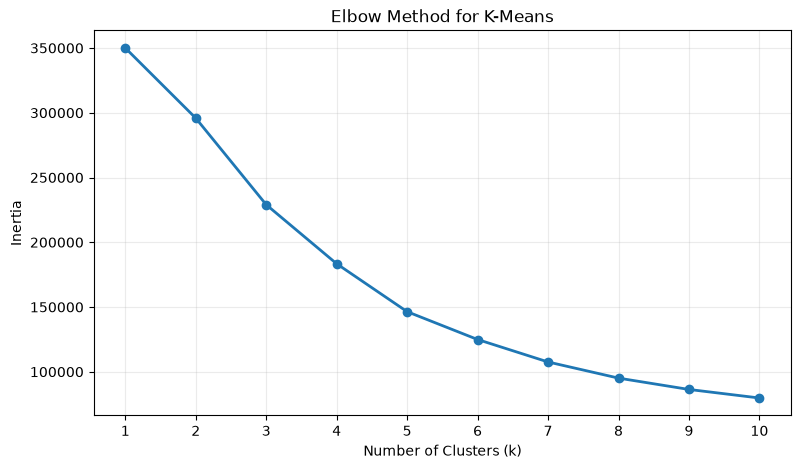

In [16]:
# Plot the Elbow Method

plt.figure(figsize=(9, 5))

plt.plot(
    range(1, 11),
    inertias,
    marker="o",
    linewidth=2
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.xticks(range(1, 11))
plt.grid(alpha=0.25)

plt.show()

<div style="
    background:linear-gradient(135deg,#0F172A,#164E63);
    border-radius:14px;
    padding:18px 22px;
    color:white;
    margin:18px 0;
">

<div style="color:#67E8F9; font-size:11px; font-weight:800; letter-spacing:1.5px;">
10 • SILHOUETTE ANALYSIS
</div>

<div style="font-size:23px; font-weight:800; margin-top:5px;">
📐 Evaluating Cluster Separation
</div>

<div style="color:#CFFAFE; font-size:14px; line-height:1.8; margin-top:8px;">
The <b>Silhouette Score</b> provides a quantitative way to evaluate how
well the data points fit within their assigned clusters.
<br><br>

The score ranges from <b>-1 to +1</b>.
Higher values generally indicate that clusters are more compact and
better separated from each other.
<br><br>

We will calculate the score for several candidate values of <b>k</b>
and use the results together with the Elbow Method to select a suitable
number of clusters.
</div>

</div>

In [18]:
# Calculate Silhouette Scores for candidate k values

silhouette_scores = {}

for k in range(2, 11):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = km.fit_predict(X_scaled)
    
    score = silhouette_score(
        X_scaled,
        labels,
        sample_size=5000,
        random_state=42
    )
    silhouette_scores[k] = score

print("Silhouette analysis completed ✓\n")

for k, score in silhouette_scores.items():
    print(f"k = {k}: Silhouette Score = {score:.4f}")

Silhouette analysis completed ✓

k = 2: Silhouette Score = 0.2339
k = 3: Silhouette Score = 0.2340
k = 4: Silhouette Score = 0.2333
k = 5: Silhouette Score = 0.2533
k = 6: Silhouette Score = 0.2655
k = 7: Silhouette Score = 0.2562
k = 8: Silhouette Score = 0.2580
k = 9: Silhouette Score = 0.2494
k = 10: Silhouette Score = 0.2418


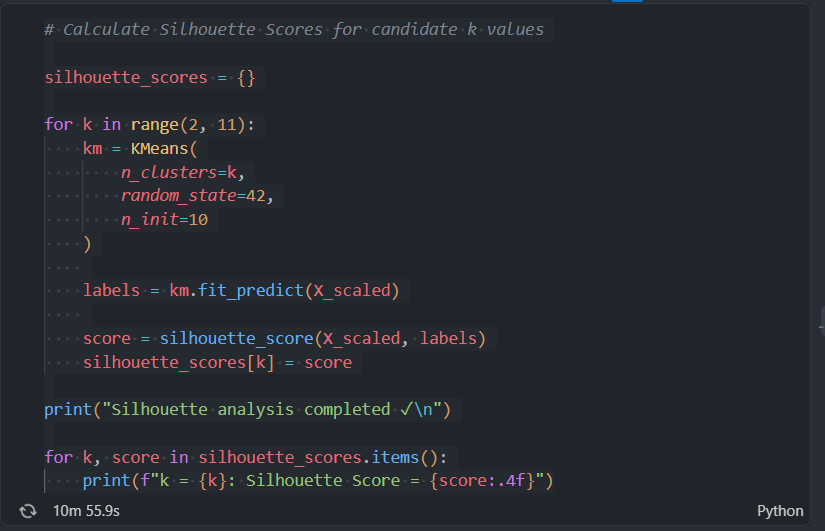

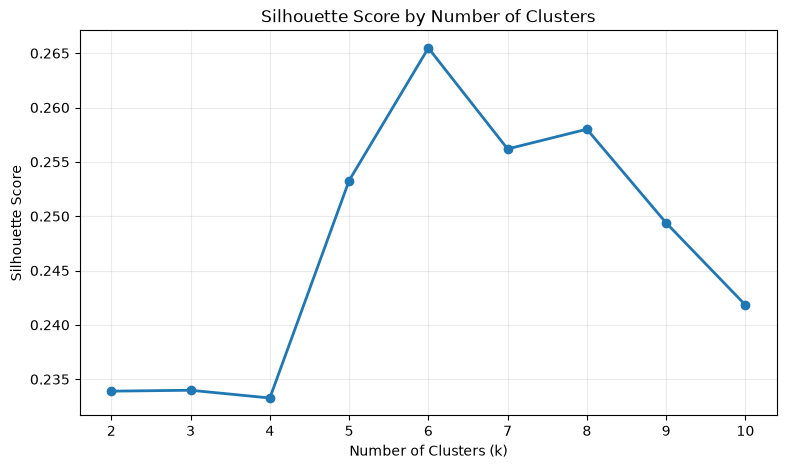

In [19]:
# Plot Silhouette Scores

plt.figure(figsize=(9, 5))

plt.plot(
    list(silhouette_scores.keys()),
    list(silhouette_scores.values()),
    marker="o",
    linewidth=2
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")
plt.xticks(range(2, 11))
plt.grid(alpha=0.25)

plt.show()

In [20]:
# Find the k with the highest Silhouette Score

best_k_silhouette = max(
    silhouette_scores,
    key=silhouette_scores.get
)

best_score = silhouette_scores[best_k_silhouette]

print(f"Best k according to Silhouette Score: {best_k_silhouette}")
print(f"Highest Silhouette Score: {best_score:.4f}")

Best k according to Silhouette Score: 6
Highest Silhouette Score: 0.2655


<div style="
    background:linear-gradient(135deg,#0F172A,#164E63);
    border-radius:14px;
    padding:18px 22px;
    color:white;
    margin:18px 0;
">

<div style="color:#67E8F9; font-size:11px; font-weight:800; letter-spacing:1.5px;">
11 • FINAL CLUSTERING MODEL
</div>

<div style="font-size:23px; font-weight:800; margin-top:5px;">
🔵 Training the Final K-Means Model
</div>

<div style="color:#CFFAFE; font-size:14px; line-height:1.8; margin-top:8px;">
After comparing different values of <b>k</b> using the Elbow Method and
Silhouette Score, we select a suitable number of clusters for the final model.
<br><br>

The final K-Means model will assign every patient to a cluster based on
similarities across the selected numerical health features.
<br><br>

These cluster labels are <b>not disease diagnoses</b>. They represent
groups of patients with similar patterns in the selected measurements.
</div>

</div>

In [21]:
# Set the final number of clusters
final_k = 3

# Train the final K-Means model
final_kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

cluster_labels = final_kmeans.fit_predict(X_scaled)

print("Final K-Means model trained successfully ✓")
print(f"Number of clusters: {final_k}")
print(f"Number of assigned samples: {len(cluster_labels)}")

Final K-Means model trained successfully ✓
Number of clusters: 3
Number of assigned samples: 70000


In [24]:
# Add cluster assignments to the original clustering data

X_clustered = X.copy()
X_clustered["Cluster"] = cluster_labels

print("Cluster labels added successfully ✓")

styled_table = X_clustered.head().style.set_table_styles([
    {"selector": "th", "props": [
        ("background-color", "#164E63"),
        ("color", "white"),
        ("font-weight", "800"),
        ("font-size", "11px"),
        ("letter-spacing", "0.5px"),
        ("padding", "10px 14px"),
        ("text-align", "center"),
        ("border", "none")
    ]},
    {"selector": "td", "props": [
        ("padding", "9px 14px"),
        ("text-align", "center"),
        ("font-size", "12.5px"),
        ("color", "#134E4A"),
        ("border-bottom", "1px solid #A7F3D0")
    ]},
    {"selector": "table", "props": [
        ("border-collapse", "collapse"),
        ("border-radius", "12px"),
        ("overflow", "hidden"),
        ("border", "1px solid #99F6E4")
    ]}
]).set_properties(**{
    "background-color": "#F0FDFA"
}).apply(
    lambda row: [
        "background-color: #ECFEFF" if row.name % 2 == 0 else "background-color: #F0FDFA"
        for _ in row
    ],
    axis=1
)

display(styled_table)

Cluster labels added successfully ✓


,age,height,weight,ap_hi,ap_lo,Cluster
0,18393,168,62.000000,110,80,0
1,20228,156,85.000000,140,90,0
2,18857,165,64.000000,130,70,0
3,17623,169,82.000000,150,100,1
4,17474,156,56.000000,100,60,0


<div style="
    background:linear-gradient(135deg,#0F172A,#164E63);
    border-radius:14px;
    padding:18px 22px;
    color:white;
    margin:18px 0;
">

<div style="color:#67E8F9; font-size:11px; font-weight:800; letter-spacing:1.5px;">
12 • CLUSTER VISUALIZATION
</div>

<div style="font-size:23px; font-weight:800; margin-top:5px;">
🎨 Visualizing Patient Clusters
</div>

<div style="color:#CFFAFE; font-size:14px; line-height:1.8; margin-top:8px;">
The final K-Means model has assigned each patient to a cluster.
Now we visualize the discovered groups using two of the selected
health measurements.
<br><br>

We use <b>Age</b> on the x-axis and <b>Cholesterol</b> on the y-axis
to observe how the discovered clusters are distributed.
<br><br>

The visualization helps us understand whether the clusters form
noticeable patterns in the selected feature space.
</div>

</div>

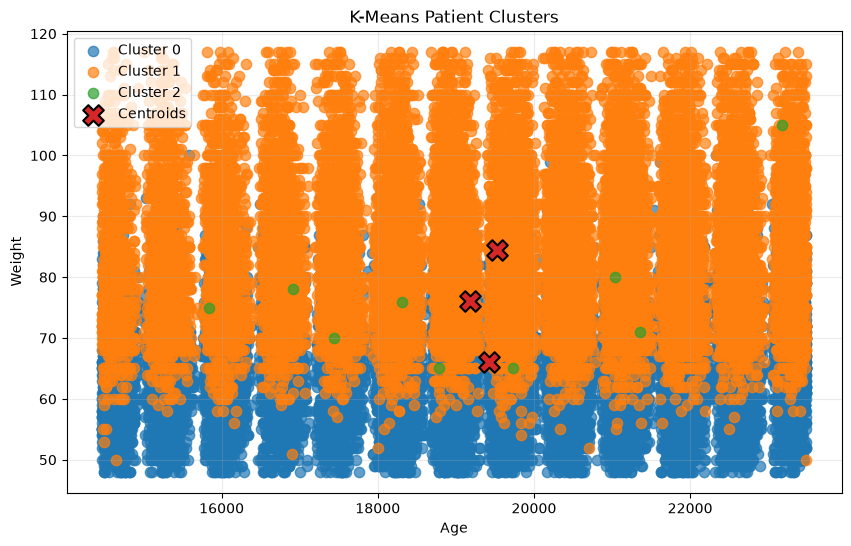

In [29]:
# Visualize the final K-Means clusters

plt.figure(figsize=(10, 6))

# Filter extreme outliers only for visualization (does not affect the model or data)
age_low, age_high = X_clustered["age"].quantile([0.01, 0.99])
weight_low, weight_high = X_clustered["weight"].quantile([0.01, 0.99])

plot_data = X_clustered[
    (X_clustered["age"].between(age_low, age_high)) &
    (X_clustered["weight"].between(weight_low, weight_high))
]

for cluster in sorted(plot_data["Cluster"].unique()):
    
    cluster_data = plot_data[
        plot_data["Cluster"] == cluster
    ]
    
    plt.scatter(
        cluster_data["age"],
        cluster_data["weight"],
        label=f"Cluster {cluster}",
        alpha=0.7,
        s=55
    )

# Plot cluster centroids in the original feature scale
centroids_scaled = final_kmeans.cluster_centers_

centroids_original = scaler.inverse_transform(centroids_scaled)

plt.scatter(
    centroids_original[:, features.index("age")],
    centroids_original[:, features.index("weight")],
    marker="X",
    s=220,
    edgecolors="black",
    linewidths=1.5,
    label="Centroids"
)

plt.xlabel("Age")
plt.ylabel("Weight")
plt.title("K-Means Patient Clusters")
plt.legend()
plt.grid(alpha=0.25)

plt.show()

<div style="
    background:linear-gradient(135deg,#0F172A,#164E63);
    border-radius:14px;
    padding:18px 22px;
    color:white;
    margin:18px 0;
">

<div style="color:#67E8F9; font-size:11px; font-weight:800; letter-spacing:1.5px;">
13 • CLUSTER INTERPRETATION
</div>

<div style="font-size:23px; font-weight:800; margin-top:5px;">
🧠 Understanding the Discovered Groups
</div>

<div style="color:#CFFAFE; font-size:14px; line-height:1.8; margin-top:8px;">
To understand what each cluster represents, we calculate the average
values of the features used during clustering.
<br><br>

This allows us to compare the groups based on <b>age, blood pressure,
cholesterol, maximum heart rate, oldpeak, and number of vessels</b>.
<br><br>

The clusters are automatically discovered by K-Means and do not represent
predefined medical diagnoses.
</div>

</div>

In [33]:
# Calculate average feature values for each cluster

cluster_summary = (
    X_clustered
    .groupby("Cluster")[features]
    .mean()
    .round(2)
)

styled_summary = (
    cluster_summary.style
    .set_caption("🧠 Average Feature Values by Cluster")
    .set_properties(**{
        "font-size": "12.5px",
        "text-align": "center",
        "padding": "9px 14px",
        "color": "#164E63",
        "border-bottom": "1px solid #A7F3D0"
    })
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("background-color", "#ECFEFF"),
                ("color", "#164E63"),
                ("font-size", "15px"),
                ("font-weight", "800"),
                ("letter-spacing", "0.5px"),
                ("text-align", "left"),
                ("padding", "12px 15px"),
                ("border", "1px solid #99F6E4")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#164E63"),
                ("color", "white"),
                ("font-weight", "800"),
                ("font-size", "11px"),
                ("letter-spacing", "0.5px"),
                ("padding", "10px 14px"),
                ("text-align", "center"),
                ("border", "none")
            ]
        },
        {
            "selector": "table",
            "props": [
                ("border-collapse", "collapse"),
                ("border-radius", "12px"),
                ("overflow", "hidden"),
                ("border", "1px solid #99F6E4")
            ]
        }
    ])
    .apply(
        lambda row: [
            "background-color: #ECFEFF" if row.name % 2 == 0 else "background-color: #F0FDFA"
            for _ in row
        ],
        axis=1
    )
)

display(styled_summary)

,age,height,weight,ap_hi,ap_lo
Cluster,,,,,
0,19441.830000,159.970000,66.120000,124.730000,87.820000
1,19503.560000,169.980000,84.550000,130.160000,107.910000
2,19175.560000,167.000000,76.110000,13404.440000,83.330000


<div style="
    background:linear-gradient(135deg,#0F172A,#164E63);
    border-radius:14px;
    padding:18px 22px;
    color:white;
    margin:18px 0;
">

<div style="color:#67E8F9; font-size:11px; font-weight:800; letter-spacing:1.5px;">
14 • FINAL RESULTS
</div>

<div style="font-size:23px; font-weight:800; margin-top:5px;">
🎯 K-Means Clustering Results
</div>

<div style="color:#CFFAFE; font-size:14px; line-height:1.8; margin-top:8px;">
The K-Means clustering process was completed successfully.
We tested different values of <b>k</b>, used the Elbow Method and
Silhouette Score to evaluate the clustering structure, and trained
the final model using the selected number of clusters.
<br><br>

The resulting clusters represent groups of patients with similar
patterns across the selected numerical health measurements.
<br><br>

These groups are <b>unsupervised patterns</b> and should not be interpreted
as medical diagnoses or predefined disease categories.
</div>

</div>

In [34]:
# Final clustering summary

print("╔══════════════════════════════════════╗")
print("║      K-MEANS CLUSTERING SUMMARY      ║")
print("╚══════════════════════════════════════╝")

print(f"\n✓ Number of samples: {len(X_clustered)}")
print(f"✓ Number of features: {len(features)}")
print(f"✓ Final number of clusters: {final_k}")
print(f"✓ Best Silhouette Score: {best_score:.4f}")

print("\nCluster distribution:")
print(X_clustered["Cluster"].value_counts().sort_index())

print("\n✓ Unsupervised clustering completed successfully!")

╔══════════════════════════════════════╗
║      K-MEANS CLUSTERING SUMMARY      ║
╚══════════════════════════════════════╝

✓ Number of samples: 70000
✓ Number of features: 5
✓ Final number of clusters: 3
✓ Best Silhouette Score: 0.2655

Cluster distribution:
Cluster
0    39289
1    30702
2        9
Name: count, dtype: int64

✓ Unsupervised clustering completed successfully!


<div style="
    background:linear-gradient(135deg,#0F172A,#164E63);
    border-radius:14px;
    padding:18px 22px;
    color:white;
    margin:18px 0;
">

<div style="color:#67E8F9; font-size:11px; font-weight:800; letter-spacing:1.5px;">
15 • DAY 1 TAKEAWAYS
</div>

<div style="font-size:23px; font-weight:800; margin-top:5px;">
🧠 What We Learned Today
</div>

<div style="color:#CFFAFE; font-size:14px; line-height:1.9; margin-top:8px;">
Today, we applied <b>unsupervised learning</b> to a healthcare dataset
using K-Means clustering.
<br><br>

We learned how to prepare numerical features, handle missing values,
scale data, test different values of <b>k</b>, and evaluate clustering
using the <b>Elbow Method</b> and <b>Silhouette Score</b>.
<br><br>

Finally, we visualized and interpreted the discovered patient groups
based on similarities in their health measurements.
<br><br>

🚀 <b>Day 1 — Unsupervised Learning & K-Means: Completed!</b>
</div>

</div>